In [1]:
import importlib

import torch

from classes.BirdDataset import *

from common.common_utils import *

In [2]:
location = "data/soundscape_recordings_amazon/"

data_folder = "recordings/"
annotations = "annotations_divided_cap10"

In [3]:
import json

with open(location + "label_encodings.json", "r") as f:
    encodings = json.load(f)

label_to_idx = encodings["label_to_idx"]
idx_to_label = {int(k): v for k, v in encodings["idx_to_label"].items()}

In [4]:
precompute_sed_samples(
    annotations_file=location + annotations,
    recordings_dir=location + data_folder,
    output_dir=location + data_folder + annotations + ".precomputed_cap5/",
    sr=32000, hop_length=256, n_mels=128, window_len=5.0,
    fmin=0.0, fmax=None,
    label_to_idx=label_to_idx,
    num_workers=8
)

precompute_sed_samples(
    annotations_file=location + annotations,
    recordings_dir=location + "recordings_clean/",
    output_dir=location + "recordings_clean/" + annotations + ".precomputed_cap5/",
    sr=32000, hop_length=256, n_mels=128, window_len=5.0,
    fmin=0.0, fmax=None,
    label_to_idx=label_to_idx,
    num_workers=8
)

Random-window SED: 100%|██████████| 21/21 [01:54<00:00,  5.43s/it]


✅ Wrote 9075 windows to data/soundscape_recordings_amazon/recordings/annotations_divided_cap10.precomputed_cap5/samples/
🧾 Manifest: data/soundscape_recordings_amazon/recordings/annotations_divided_cap10.precomputed_cap5/manifest.csv


Random-window SED: 100%|██████████| 21/21 [01:53<00:00,  5.41s/it]


✅ Wrote 9085 windows to data/soundscape_recordings_amazon/recordings_clean/annotations_divided_cap10.precomputed_cap5/samples/
🧾 Manifest: data/soundscape_recordings_amazon/recordings_clean/annotations_divided_cap10.precomputed_cap5/manifest.csv


In [7]:
train_dataset = BirdDataset(
    data_path = location + data_folder,
    annotations_file = location + annotations,
    split = "val",
    label_to_idx = label_to_idx,
    target_type = "tf",
    precomputed = True,
    precomputed_dir = location + data_folder + annotations + ".precomputed_cap5/",
)

val_dataset = BirdDataset(
    data_path = location + data_folder,
    annotations_file = location + annotations,
    split = "val",
    label_to_idx = label_to_idx,
    target_type = "tf",
    include_overlaps = True,
    precomputed = False,
)


print(len(train_dataset), len(val_dataset))

271 280


In [20]:
import pandas as pd

annotations_df = pd.read_csv(location + annotations + ".csv", sep=",")

In [6]:
show_sample_idx = 55

,Filename,Start Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Species eBird Code
316,PER_006_S08_20190116_100007Z.flac,2690.1,2692.4,1142,3321,bubwre1


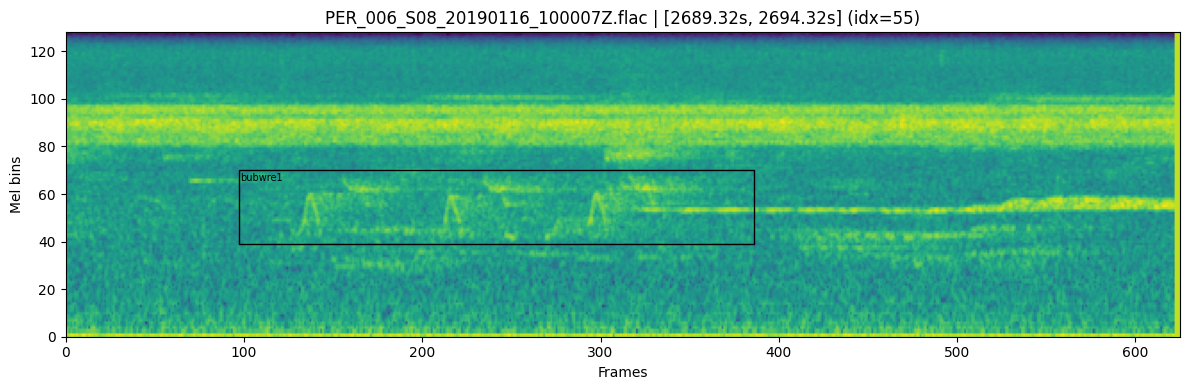

,Filename,Start Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Species eBird Code
557,PER_008_S01_20190120_100007Z.flac,1493.7,1495.8,1329,3670,whwbec1
329,PER_008_S01_20190120_100007Z.flac,1494.7,1495.2,198,873,bucmot4


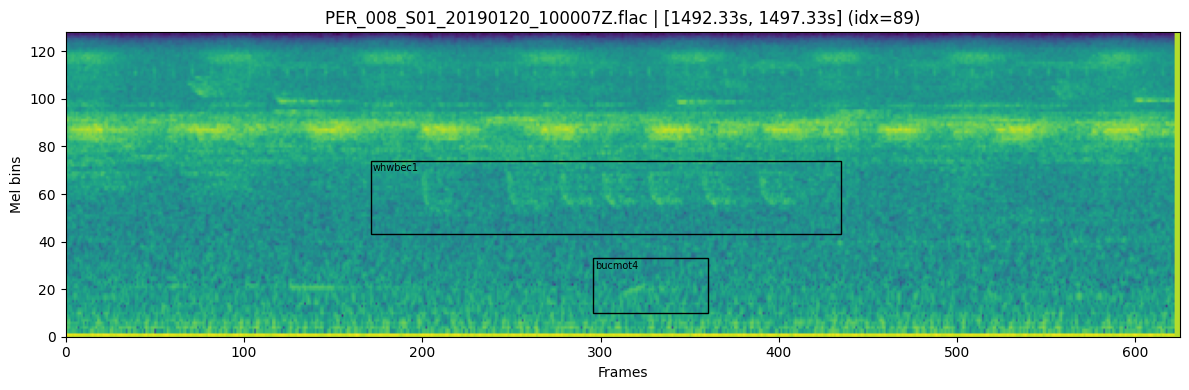

PER_008_S01_20190120_100007Z.flac 1492.325109630571 1497.325109630571


In [7]:
# Visualize an existing dataset window
rows = plot_window_with_annotations(ds=train_dataset, annotations_df=annotations_df, idx=show_sample_idx)

# Find a random window with >= n samples (fully contained) and visualize it
idx, fname, ws, we, rows = find_random_window_with_n_samples(
    ds=train_dataset,
    annotations_df=annotations_df,
    n=2,
    mode="at_least",
    fully_contained=True,
    seed=498
)
if idx is not None:
    plot_window_with_annotations(ds=train_dataset, annotations_df=annotations_df, idx=idx)

print(fname, ws, we)

In [6]:
from torch.utils.data import ConcatDataset

train_dataset = BirdDataset(
    data_path = location + data_folder,
    annotations_file = location + annotations,
    label_to_idx = label_to_idx,
    target_type = "tf",
    precomputed = True,
    window_len=5.0,
    precomputed_dir = location + data_folder + annotations + ".precomputed_cap5/",
)
train_clean_dataset = BirdDataset(
    data_path = location + "recordings_clean/", 
    annotations_file = location + annotations,
    label_to_idx = label_to_idx,
    target_type = "tf",
    precomputed = True,
    window_len=5.0,
    precomputed_dir=location + "recordings_clean/" + annotations + ".precomputed_cap5/",
    )
train_dataset = ConcatDataset([train_dataset, train_clean_dataset])

val_dataset = BirdDataset(
    data_path = location + data_folder,
    annotations_file = location + annotations,
    label_to_idx = label_to_idx,
    split = "val",
    target_type = "tf",
    precomputed = True,
    window_len=5.0,
    precomputed_dir=location + data_folder + annotations + ".precomputed_cap5",
    )

print(len(train_dataset), len(val_dataset))

14948 1646


In [8]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4070


In [4]:
from classes.BirdModels import BirdCRNN
from torchinfo import summary

model = BirdCRNN(n_mels=128, n_classes=len(label_to_idx), cnn_channels=64, hidden_size=128, gru_num_layers=3)

In [7]:
mel, target = train_dataset[0]
B, C, F, T = 1, *mel.shape

summary(
    model,
    input_size=(B, C, F, T)
)

Layer (type:depth-idx)                   Output Shape              Param #
BirdCRNN                                 [1, 28, 625]              --
├─Sequential: 1-1                        [1, 64, 32, 625]          --
│    └─Conv2d: 2-1                       [1, 64, 128, 625]         960
│    └─BatchNorm2d: 2-2                  [1, 64, 128, 625]         128
│    └─ReLU: 2-3                         [1, 64, 128, 625]         --
│    └─MaxPool2d: 2-4                    [1, 64, 64, 625]          --
│    └─Dropout: 2-5                      [1, 64, 64, 625]          --
│    └─Conv2d: 2-6                       [1, 128, 64, 625]         122,880
│    └─BatchNorm2d: 2-7                  [1, 128, 64, 625]         256
│    └─ReLU: 2-8                         [1, 128, 64, 625]         --
│    └─MaxPool2d: 2-9                    [1, 128, 32, 625]         --
│    └─Dropout: 2-10                     [1, 128, 32, 625]         --
│    └─Conv2d: 2-11                      [1, 128, 32, 625]         147,456
│ 

In [32]:
# stats = benchmark_pipeline(model, trainloader, device=device, batches=50, use_amp=True)

In [5]:
import gc
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
torch.cuda.empty_cache()
gc.collect()

0

In [8]:
import scripts.train_script as TS

from common.logging_extensions import now_ts

In [11]:
import importlib
from torch.utils.data import DataLoader, Subset
from scripts.train_script import create_dataloaders

from classes.BirdModels import *
importlib.reload(TS)

cfg = TS.TrainConfig(
    location=location,
    data_folder=data_folder,
    annotations_file=annotations,
    precomputed=True,
    precomputed_dirs = [
        "recordings/" + annotations + ".precomputed_cap5/"
    ],
    n_mels=128,
    target_type="time",
    batch_size=32,
    epochs=100,
    metric_thr=0.3,
    lr=1e-3,
    num_workers=os.cpu_count() // 2,
    amp="off",
    pos_weight="none",
    seed=1657,
    logs_base="logs/",
    run_name="overfit_time",
)

model = BirdCRNN(
    n_mels=cfg.n_mels,
    n_classes=len(label_to_idx),
    dropout=0.0,
)
cfg.model = model

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

full_train_loader, full_val_loader = create_dataloaders(cfg, label_to_idx)

train_ds = full_train_loader.dataset
val_ds   = full_val_loader.dataset

n_train = 4
n_val   = len(val_ds)

g = torch.Generator().manual_seed(cfg.seed)

train_indices = torch.randperm(len(train_ds), generator=g)[:n_train].tolist()
val_indices   = torch.randperm(len(val_ds),   generator=g)[:min(128, len(val_ds))].tolist()

train_subset = Subset(train_ds, train_indices)
val_subset   = Subset(val_ds,   val_indices)

train_overfit_loader = DataLoader(
    train_subset,
    batch_size=n_train,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

val_overfit_loader = DataLoader(
    val_subset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [12]:
TS.fit(cfg, label_to_idx, train_overfit_loader, val_overfit_loader, mem_save=False)

2025-11-21 20:50:28 | INFO | train samples: 4, val samples: 128
2025-11-21 20:50:28 | INFO | config: {
  "location": "data/soundscape_recordings_amazon/",
  "data_folder": "recordings/",
  "annotations_file": "annotations_divided_cap10",
  "precomputed": true,
  "precomputed_dirs": [
    "recordings/annotations_divided_cap10.precomputed_cap5/"
  ],
  "n_mels": 128,
  "window_len": 10.0,
  "batch_size": 32,
  "num_workers": 8,
  "target_type": "time",
  "include_overlaps": true,
  "lr": 0.001,
  "epochs": 100,
  "model_name": "BirdCRNN",
  "model": "BirdCRNN",
  "amp": "off",
  "pos_weight": "none",
  "save_top_k": 3,
  "metric_thr": 0.3,
  "monitor": "val_tf_f1_macro",
  "monitor_mode": "max",
  "seed": 1657,
  "logs_base": "logs/",
  "run_name": "overfit_time",
  "paths": {
    "root": "logs/annotations_divided_cap10\\overfit_time",
    "logs_dir": "logs/annotations_divided_cap10\\overfit_time\\logs",
    "ckpt_dir": "logs/annotations_divided_cap10\\overfit_time\\checkpoints",
    "lo

{'root': 'logs/annotations_divided_cap10\\overfit_time',
 'logs_dir': 'logs/annotations_divided_cap10\\overfit_time\\logs',
 'ckpt_dir': 'logs/annotations_divided_cap10\\overfit_time\\checkpoints',
 'log_file': 'logs/annotations_divided_cap10\\overfit_time\\logs\\train.log',
 'csv_file': 'logs/annotations_divided_cap10\\overfit_time\\logs\\metrics.csv',
 'cfg_file': 'logs/annotations_divided_cap10\\overfit_time\\config.json',
 'plot_file': 'logs/annotations_divided_cap10\\overfit_time\\logs\\training_curves.html'}

In [13]:
from common import plotting

plots1 = plotting.generate_all_plots_for_run("./logs/" + annotations + "/overfit_tf")


plots2 = plotting.generate_all_plots_for_run("./logs/" + annotations + "/overfit_time")

[generate_all_plots_for_run] metrics_csv=logs\annotations_divided_cap10\overfit_tf\logs\metrics.csv
[generate_all_plots_for_run] stats_dir=logs\annotations_divided_cap10\overfit_tf\logs\stats
[plot_metric_matrix] Saved: logs\annotations_divided_cap10\overfit_tf\logs\stats\losses.png
[plot_metric_matrix] Saved: logs\annotations_divided_cap10\overfit_tf\logs\stats\tf_f1_dice.png
[plot_metric_matrix] Saved: logs\annotations_divided_cap10\overfit_tf\logs\stats\tf_prec_rec.png
[plot_metric_matrix] Saved: logs\annotations_divided_cap10\overfit_tf\logs\stats\tf_fracs.png
[plot_metric_matrix] Saved: logs\annotations_divided_cap10\overfit_tf\logs\stats\time_f1_dice.png
[plot_metric_matrix] Saved: logs\annotations_divided_cap10\overfit_tf\logs\stats\time_prec_rec.png
[plot_metric_matrix] Saved: logs\annotations_divided_cap10\overfit_tf\logs\stats\time_fracs.png
[generate_all_plots_for_run] metrics_csv=logs\annotations_divided_cap10\overfit_time\logs\metrics.csv
[generate_all_plots_for_run] stats